In [74]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
class UnivariateLinearRegressor:
    def __init__(self,epochs,lr):
        self.epochs = epochs
        self.lr = lr
        self.w = 0
        self.b = 0
        self.loss_history = []

    def fit(self,x,y):
        n = len(x)
        for epoch in range(self.epochs):
            y_pred = self.w * x + self.b
            loss = np.mean((y-y_pred)**2)
            self.loss_history.append(loss)
            dw = (-2/n) * np.sum((y-y_pred)* x) 
            db = (-2/n) * np.sum(y-y_pred)
            self.w -= self.lr * dw
            self.b -= self.b * db
            if epoch % 100 == 0:
                print(f"Iteration {epoch+1}: MSE Loss ={loss}")
        

    def predict(self,x):
        return self.w * x +self.b
    
    def get_loss_history(self):
        return self.loss_history
        

In [76]:
# Preparing dummy linear data following the equation y = 5 + 0.5x
X = [x for x in range(100)]
y = [5+0.5*x for x in X]

df = pd.DataFrame({"X":X,'y':y})
df.head()

,X,y
0,0,5.0
1,1,5.5
2,2,6.0
3,3,6.5
4,4,7.0


In [77]:
X = df['X'].values
y = df['y'].values

In [78]:
print("shape of X:",X.shape)
print("shape of y",y.shape)

shape of X: (100,)
shape of y (100,)


standardization

In [79]:
X.std()

np.float64(28.86607004772212)

In [80]:
X_mean = X.mean()
X_std = X.std()
y_mean = y.mean()
y_std = y.std()

In [81]:
X = (X-X_mean) / X_std
y = (y-y_mean) / y_std

In [82]:
model = UnivariateLinearRegressor(epochs=500,lr=0.01)
model.fit(X,y)

Iteration 1: MSE Loss =1.0
Iteration 101: MSE Loss =0.017587946605721497
Iteration 201: MSE Loss =0.0003093358658057063
Iteration 301: MSE Loss =5.440582691026461e-06
Iteration 401: MSE Loss =9.568867787377935e-08


Text(0, 0.5, 'MSE Loss')

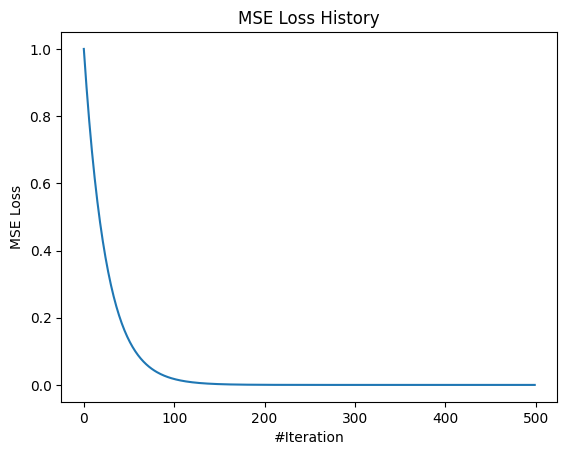

In [83]:
#plot learning curve
loss_history = model.get_loss_history()
sns.lineplot(loss_history)
plt.title("MSE Loss History")
plt.xlabel("#Iteration")
plt.ylabel("MSE Loss")

In [86]:
#prediction
x_t = np.array(4.5)
x_t_norm = (x_t - X_mean) / X_std
y_pred_norm = model.predict(x_t_norm)
y_pred = y_pred_norm * y_std + y_mean
y_pred

np.float64(7.250923039665771)

In [88]:
5 + 0.5 * x_t  #correct output

np.float64(7.25)